# Analise Exploratória

## Baseline

In [35]:
#TODO: Copiar as analises do paper

## Nova base de dados

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords

df = pd.read_csv("../data/classification_dataset_augmented.csv")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/fernando/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/fernando/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
print(df.shape)
print(df.info())

(6937, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6937 entries, 0 to 6936
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      6925 non-null   object
 1   is_rule   6937 non-null   int64 
 2   ID        6061 non-null   object
 3   metadata  862 non-null    object
dtypes: int64(1), object(3)
memory usage: 216.9+ KB
None


In [8]:
df[df['Text'].isnull()]

,Text,is_rule,ID,metadata
2033,NaN,0,NaN,NaN
2034,NaN,0,NaN,NaN
2035,NaN,0,NaN,NaN
2036,NaN,0,NaN,NaN
3627,NaN,0,NaN,NaN
3628,NaN,0,NaN,NaN
3629,NaN,0,NaN,NaN
3642,NaN,0,NaN,NaN
3643,NaN,0,NaN,NaN
3644,NaN,0,NaN,NaN


In [23]:
df_care = df.dropna(subset=['Text'])

>  Estatísticas básicas por classe

In [24]:
df_care['n_tokens'] = df_care['Text'].apply(lambda x: len(word_tokenize(x)))
df_care['n_chars'] = df_care['Text'].apply(len)
print(df_care.groupby("is_rule")[["n_tokens", "n_chars"]].describe())

        n_tokens                                                     n_chars  \
           count       mean        std  min   25%   50%   75%    max   count   
is_rule                                                                        
0         5109.0  28.525347  31.045367  2.0  14.0  23.0  34.0  570.0  5109.0   
1         1816.0  26.450991  14.293493  5.0  17.0  23.0  33.0  160.0  1816.0   

                                                                   
               mean         std   min   25%    50%    75%     max  
is_rule                                                            
0        157.811313  159.766989   3.0  78.0  128.0  187.0  2768.0  
1        146.924559   77.764583  32.0  93.0  131.0  181.0   891.0  


> Distribuição de comprimento por classe

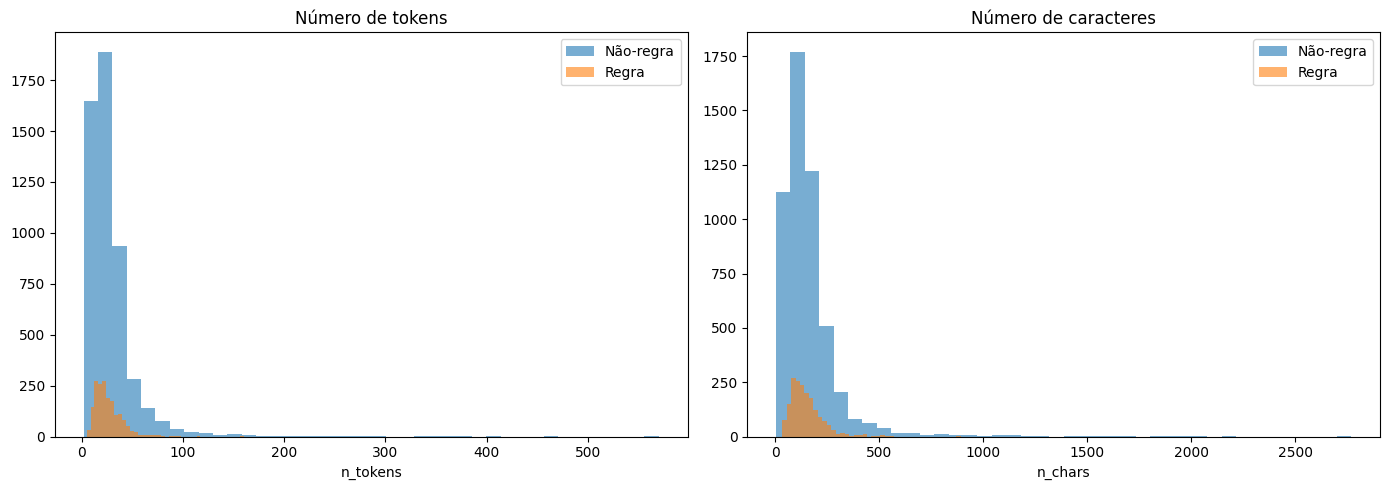

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ["n_tokens", "n_chars"],
                           ["Número de tokens", "Número de caracteres"]):
    for label, grp in df_care.groupby("is_rule"):
        name = "Regra" if label == 1 else "Não-regra"
        ax.hist(grp[col], bins=40, alpha=0.6, label=name)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()
# plt.savefig("distribuicao_comprimento.png", dpi=150)

> Análise de marcadores linguísticos por classe

In [28]:
# Palavras-chave deônticas, quantitativas e subjetivas
# (as mesmas usadas no filtro automático do artigo)
deontic     = ["must","shall","should","may","could","prohibit","not","cannot"]
quantitative= ["less than","greater than","at least","equal","higher than",
               "more than","lower than","not exceed","minimum","maximum"]
subjective  = ["should be","recommended","preferred","advisable"]

def count_keywords(text, keywords):
    text = text.lower()
    return sum(1 for kw in keywords if kw in text)

df_care["n_deontic"]      = df_care["Text"].apply(lambda x: count_keywords(x, deontic))
df_care["n_quantitative"] = df_care["Text"].apply(lambda x: count_keywords(x, quantitative))
df_care["n_subjective"]   = df_care["Text"].apply(lambda x: count_keywords(x, subjective))

# Médias por classe
print(df_care.groupby("is_rule")[
    ["n_deontic","n_quantitative","n_subjective"]
].mean().round(3))

         n_deontic  n_quantitative  n_subjective
is_rule                                         
0            0.873           0.253         0.426
1            1.129           0.290         0.556


> Balanceamento e origem geográfica

In [31]:
# Distribuição geral das classes
print(df_care["is_rule"].value_counts())
print(df_care["is_rule"].value_counts(normalize=True).round(3))

# Por país de origem
# print(df_care.groupby(["ID", "is_rule"]).size().unstack())

is_rule
0    5109
1    1816
Name: count, dtype: int64
is_rule
0    0.738
1    0.262
Name: proportion, dtype: float64


> Palavras mais frequentes por classe (excluindo stopwords)

In [32]:
stop = set(stopwords.words("english"))

def top_words(texts, n=20):
    tokens = []
    for t in texts:
        tokens += [w.lower() for w in word_tokenize(t)
                   if w.isalpha() and w.lower() not in stop]
    return Counter(tokens).most_common(n)

print("=== TOP 20 PALAVRAS — REGRAS ===")
print(top_words(df_care[df_care["is_rule"]==1]["Text"]))

print("\n=== TOP 20 PALAVRAS — NÃO REGRAS ===")
print(top_words(df_care[df_care["is_rule"]==0]["Text"]))

=== TOP 20 PALAVRAS — REGRAS ===
[('building', 402), ('must', 363), ('water', 253), ('system', 225), ('shall', 214), ('dwelling', 192), ('air', 170), ('least', 158), ('rate', 154), ('energy', 153), ('provided', 152), ('area', 152), ('heat', 147), ('ventilation', 140), ('installed', 137), ('used', 133), ('one', 121), ('use', 116), ('heating', 116), ('space', 116)]

=== TOP 20 PALAVRAS — NÃO REGRAS ===
[('building', 1667), ('water', 588), ('shall', 550), ('must', 548), ('system', 495), ('buildings', 447), ('ventilation', 445), ('energy', 444), ('section', 442), ('air', 440), ('dwelling', 433), ('provided', 429), ('use', 425), ('least', 389), ('used', 382), ('fire', 366), ('one', 364), ('rate', 363), ('heat', 352), ('means', 351)]


> Análise de n-gramas (bigramas mais distintivos)

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF com bigramas para identificar os mais discriminativos
tfidf = TfidfVectorizer(ngram_range=(2,2), max_features=30,
                        stop_words="english")

rules_text    = df_care[df_care["is_rule"]==1]["Text"].tolist()
nonrules_text = df_care[df_care["is_rule"]==0]["Text"].tolist()

tfidf.fit(rules_text + nonrules_text)

# Score médio de TF-IDF por classe
import scipy.sparse as sp
X = tfidf.transform(rules_text + nonrules_text)
feature_names = tfidf.get_feature_names_out()

X_rules    = tfidf.transform(rules_text).mean(axis=0)
X_nonrules = tfidf.transform(nonrules_text).mean(axis=0)

scores = np.array(X_rules - X_nonrules).flatten()
top_rule_bigrams = [(feature_names[i], scores[i])
                    for i in np.argsort(scores)[::-1][:15]]
print("Bigramas mais associados a REGRAS:")
print(top_rule_bigrams)

Bigramas mais associados a REGRAS:
[('wheelchair users', np.float64(0.010007237702989799)), ('primary energy', np.float64(0.004738634609791282)), ('district heat', np.float64(0.0036126974886393033)), ('cable routes', np.float64(0.00322448580409458)), ('parking spaces', np.float64(0.003207790883880523)), ('vehicle charge', np.float64(0.002926425222806335)), ('electric vehicle', np.float64(0.002926425222806335)), ('charge point', np.float64(0.002632911294850349)), ('floor area', np.float64(0.002238488671202382)), ('mechanical ventilation', np.float64(0.0018692572477115761)), ('major renovation', np.float64(0.001635376966177277)), ('residential building', np.float64(0.0013954125487277988)), ('flow rate', np.float64(0.0013069760771092093)), ('energy rate', np.float64(0.0012360441578274225)), ('hot water', np.float64(0.0010477521122255196))]


# Resumo

| Análise | O que revela | Relevância para o classificador |
| :--- | :--- | :--- |
| Replicação das figuras do artigo | Baseline comparável | Valida seu ambiente |
| Comprimento por classe | Regras são mais longas | Feature simples e poderosa |
| Marcadores deônticos/quantitativos | Quais palavras separam as classes | Fundamenta a escolha do modelo |
| Balanceamento por origem | Proporção real do desbalanceamento | Define estratégia de treino |
| Top palavras por classe | Vocabulário característico | Interpretabilidade |
| Bigramas TF-IDF | Padrões de linguagem regulatória | Feature engineering |

# Analise dados prontos 

In [ ]:
df_binary = pd.read_csv('../data/Single-Clauses-Data_Binary-Classification.csv', encoding='latin-1')
df_binary.shape

/tmp/ipykernel_13433/3616424739.py:1: DtypeWarning: Columns (20,21,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df_binary = pd.read_csv('../data/Single-Clauses-Data_Binary-Classification.csv', encoding='latin-1')


(25867, 73)

In [15]:
df_binary.columns

Index(['1_UK_DocG_Sanitation', 'Others',
       'However, building work may be subject to more than one requirement of the Building Regulations.',
       'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'self-contained',
       'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24',
       'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28',
       'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32',
       'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36',
       'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40',
       'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44',
       'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48',
       'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52',
       'Unnamed: 53', '

In [19]:
df_binary_care = df_binary[['1_UK_DocG_Sanitation', 'Others','However, building work may be subject to more than one requirement of the Building Regulations.',]].copy()
df_binary_care.shape, df_binary_care.isnull().sum()

((25867, 3),
 1_UK_DocG_Sanitation                                                                               10
 Others                                                                                              0
 However, building work may be subject to more than one requirement of the Building Regulations.     0
 dtype: int64)

In [26]:
df_duplicated = df_binary_care[df_binary_care['However, building work may be subject to more than one requirement of the Building Regulations.'].duplicated()]
df_duplicated.iloc[78]['However, building work may be subject to more than one requirement of the Building Regulations.']

'Where modelling or monitoring data is required, expert advice should be sought.'

In [27]:
df_binary_care[df_binary_care['However, building work may be subject to more than one requirement of the Building Regulations.'] == 'Where modelling or monitoring data is required, expert advice should be sought.']


,1_UK_DocG_Sanitation,Others,"However, building work may be subject to more than one requirement of the Building Regulations."
1210,122_UK_DocF_V1_Ventilation,Others,Where modelling or monitoring data is required...
1426,70_UK_DocF_V2_Ventilation,Others,Where modelling or monitoring data is required...
3797,122_UK_DocF_V1_Ventilation,Others,Where modelling or monitoring data is required...
4013,70_UK_DocF_V2_Ventilation,Others,Where modelling or monitoring data is required...
6385,122_UK_DocF_V1_Ventilation,Others,Where modelling or monitoring data is required...
6601,70_UK_DocF_V2_Ventilation,Others,Where modelling or monitoring data is required...
8972,122_UK_DocF_V1_Ventilation,Others,Where modelling or monitoring data is required...
9188,70_UK_DocF_V2_Ventilation,Others,Where modelling or monitoring data is required...
11559,122_UK_DocF_V1_Ventilation,Others,Where modelling or monitoring data is required...
11775,70_UK_DocF_V2_Ventilation,Others,Where modelling or monitoring data is required...


In [22]:
df_binary_care[~df_binary_care['However, building work may be subject to more than one requirement of the Building Regulations.'].duplicated()]

,1_UK_DocG_Sanitation,Others,"However, building work may be subject to more than one requirement of the Building Regulations."
0,2_UK_DocG_Sanitation,Others,Consideration of technical risk.
1,3_UK_DocG_Sanitation,Others,In relation to the installation of new and rep...
2,4_UK_DocG_Sanitation,Others,Attention should be paid in particular to the ...
3,5_UK_DocG_Sanitation,Others,How to use this.
4,6_UK_DocG_Sanitation,Others,In this document the following conventions hav...
...,...,...,...
2581,1_UK_DocG_Sanitation,Others,"However, building work may be subject to more ..."
2606,26_UK_DocG_Sanitation,Others,GENERAL GUIDANCE.
2863,53_UK_DocM_V1_AccessAndUseOfBuildings,Others,General provisions.
4062,121_UK_DocF_V2_Ventilation,Others,General.
